### Simulation and analysis of Bernoulli, Binomial and Geometric Distributions
#### Objectives:

- Define the Bernoulli, Binomial, and geometric distributions and their PMFs, means, and variance.
- Simulate samples, compute empirical probabilities, and compare to exact probabilities.
- Visiualize comparisons and show convergence as sample size growth


In [2]:
pip install numpy matplotlib

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/12.6 MB 8.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.6 MB 9.6 MB/s eta 0:00:01
   --------------------- ------------------ 6.8/12.6 MB 11.0 MB/s eta 0:00:01
   ----------------------------- ---------- 9.4/12.6 MB 11.5 MB/s eta 0:00:01
   ------------------------------------- -- 11.8/12.6 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 11.1 MB/s  0:00:01
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.5 MB 12.0 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 12.0 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 12.0 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 11.1 MB/s  0:00:00
   -----------

In [7]:
# imports
import numpy as np 
import matplotlib.pyplot as plt 
from math import comb
np.random.seed(42)
plt.rcParams['figure.figsize'] = [8, 4]
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [8]:
from collections import Counter

def empirical_pmf(samples, support= None):
    """Compute the empirical probability mass function (PMF) of a set of samples."""
    counts = Counter(samples)
    n = len(samples)
    if support is None:
        support = sorted(counts.keys())
    probs = np.array([counts.get(k, 0) / n for k in support])
    return np.array(support), probs

def plot_pmf_comparison(x_val, emp_probs, exact_prob, title, xlabel, legend_loc='best'):
    """Plot the empirical PMF and the exact PMF for comparison."""
    width = 0.4
    xs = np.arange(len(x_val))
    plt.bar(xs - width/2, emp_probs, width=width, label='Empirical PMF', alpha=0.7)
    plt.bar(xs + width/2, exact_prob, width=width, label='Exact PMF', alpha=0.7)
    plt.xticks(xs, x_val)
    plt.xlabel(xlabel)
    plt.ylabel('Probability')
    plt.title(title)
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    plt.show()

def tv_distance(p, q):
    """Compute the total variation distance between two probability distributions."""
    p = np.asanyarray(p)
    q = np.asanyarray(q)
    return 0.5 * np.sum(np.abs(p - q))

### Bernoulli Distribution
#### Definition : X ~ Bernoulli(p) takes values 1 (sucess) with probability p and 0 otherwise

- PMF : P(X=1)=p, P(X=0)=1-p
- Mean : E[X]=p
- Variance: Var(X)=p(1-p)

Bernoulli: p = 0.3 N = 1000
Emprical P(1)= 0.288 Exact P(1)= 0.3
Empricial mean = 0.288 Exact mean = 0.3
Empirical variance = 0.20505599999999993 Exact variance = 0.21
Total variation distance = 0.01200000000000001


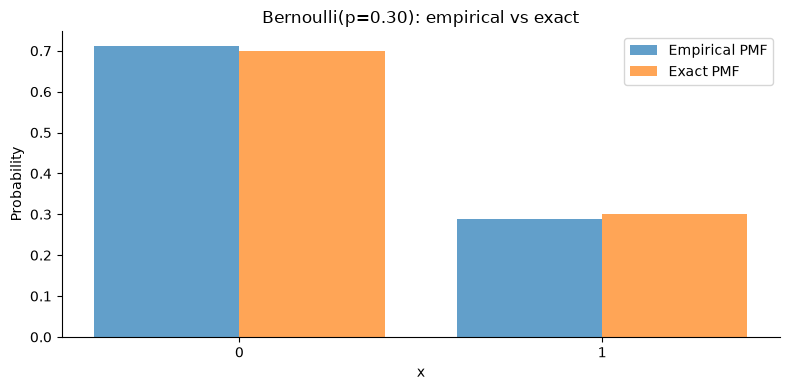

In [9]:
# bernoulli simulation and comparison
p = 0.3
N = 1000
X = np.random.binomial(n=1, p=p, size=N)

support = [0, 1]
exact = np.array([1-p, p])
xs, emp = empirical_pmf(X, support=support)

print('Bernoulli: p =', p, 'N =', N)
print('Emprical P(1)=',emp[1], 'Exact P(1)=',p)
print('Empricial mean =', X.mean(), 'Exact mean =', p)
print('Empirical variance =', X.var(ddof=0), 'Exact variance =', p*(1-p))
print('Total variation distance =', tv_distance(emp, exact))

plot_pmf_comparison(xs, emp, exact, title='Bernoulli(p=%.2f): empirical vs exact' % p, xlabel='x', legend_loc='best')



### Binomial Distribution
#### Definition : Y ~ Binomial(n,p) is the count of success in n independent Bernoulli(p) trials
- PMF : P(Y=k) = C(n,k)p^k+(1-p)p^(n-k) ; k = 0, 1,.., n and n in N
- Mean : E(Y) = np
- Variance : Var[Y] = np(1-p)


Binomial: n = 10 p = 0.3 N = 20000
Emprical P(5)= 0.10375 Exact P(5)= 0.10291934519999994
Empricial mean = 3.006 Exact mean = 3.0
Empirical variance = 2.094464 Exact variance = 2.0999999999999996
Total variation distance = 0.004751030799999961


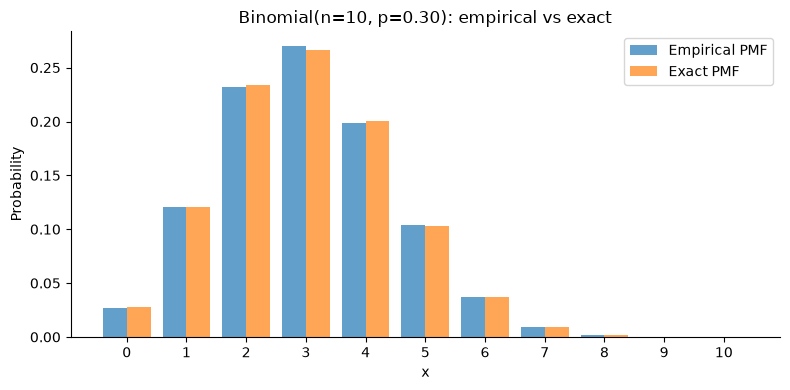

In [10]:
# Binomial simulation and comparison
n = 10  
p = 0.3
N = 20000
Y = np.random.binomial(n=n, p=p, size=N)

support = np.arange(n+1)
exact = np.array([comb(n, k) * (p**k) * ((1-p)**(n-k)) for k in support])
xs, emp = empirical_pmf(Y, support=support)

print('Binomial: n =', n, 'p =', p, 'N =', N)
print('Emprical P(5)=',emp[5], 'Exact P(5)=',exact[5])
print('Empricial mean =', Y.mean(), 'Exact mean =', n*p)
print('Empirical variance =', Y.var(ddof=0), 'Exact variance =', n*p*(1-p))
print('Total variation distance =', tv_distance(emp, exact))

plot_pmf_comparison(xs, emp, exact, title='Binomial(n=%d, p=%.2f): empirical vs exact' % (n, p), xlabel='x')

### Geometric Distribution
#### We use the convention : Z ~ Geometric(p) is the number of trials until the first success, with support {1,2,....}
- PMF : P(Z=k) = (1-p)^(k-1)p
- Mean : E(Z) = 1/p
- Variance: Var(Z)= (1-p)/p^2

Geometric: p = 0.3 N = 50000
Mass P(z<=K) exact = 0.9952524384900568
Mass P(z<=K) empirical = 0.9953
Empirical mean = 3.32216 Exact mean = 3.3333333333333335
Empirical variance = 7.6655729344 Exact variance = 7.777777777777778
Total variation distance = 0.0028777425187768916


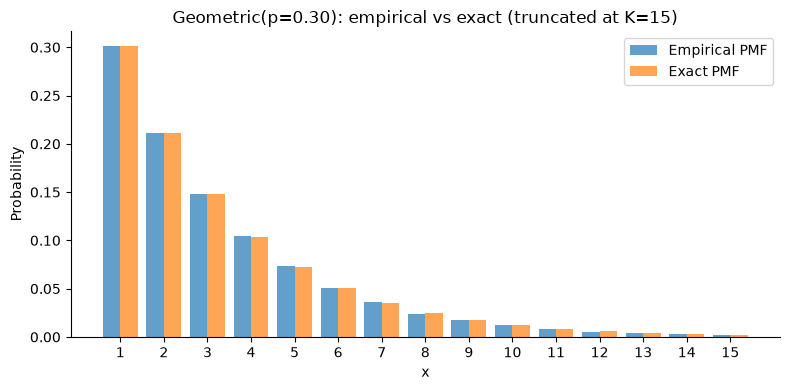

In [11]:
# Geometric simulation and comparison (support starts from 1 for geometric distribution)
p = 0.3
N = 50000
Z = np.random.geometric(p=p, size=N)

# Comparing over a finite support up to K
K = 15
support = list(range(1, K+1))
exact = np.array([(1-p)**(k-1) * p for k in support])
xs, emp = empirical_pmf([z if z<=K else K for z in Z], support=support)

# Adjusting the empirical to only count z<=K
mask = (Z <= K)
xs, emp = empirical_pmf(Z[mask], support=support)

print('Geometric: p =', p, 'N =', N)
print('Mass P(z<=K) exact =', exact.sum())
print('Mass P(z<=K) empirical =', mask.mean())
print('Empirical mean =', Z.mean(), 'Exact mean =', 1/p)
print('Empirical variance =', Z.var(ddof=0), 'Exact variance =', (1-p)/(p**2))
print('Total variation distance =', tv_distance(emp, exact/exact.sum()))

plot_pmf_comparison(xs, emp, exact/exact.sum(), title='Geometric(p=%.2f): empirical vs exact (truncated at K=%d)' % (p, K), xlabel='x', legend_loc='best')



### Convergence with sample size
#### We illustrate how empirical distributions approach exact distributions as N increases by tracking total variation distance 

Total Variation Distances for increasing N:
Bernoulli [(100, np.float64(0.07)), (1000, np.float64(0.009)), (10000, np.float64(0.0012)), (100000, np.float64(0.0024))]
Binomial [(100, np.float64(0.0601)), (1000, np.float64(0.0365)), (10000, np.float64(0.0101)), (100000, np.float64(0.0023))]
Geometric [(100, np.float64(0.1608)), (1000, np.float64(0.0363)), (10000, np.float64(0.0108)), (100000, np.float64(0.0042))]


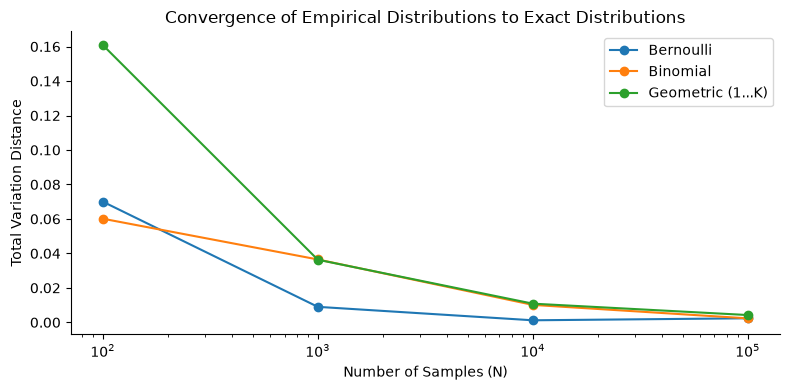

In [12]:
# Convergence of empirical distribution to exact distribution as N increases
Ns = [100, 1000, 10000, 100000]
p = 0.3
n = 10
K = 15

bern_tv = []
binom_tv = []
geom_tv = []

for N in Ns:
    # Bernoulli
    X = np.random.binomial(n=1, p=p, size=N)
    support_b = [0, 1]
    exact_b = np.array([1-p, p])
    _, emp_b = empirical_pmf(X, support=support_b)
    bern_tv.append(tv_distance(emp_b, exact_b))

    # Binomial
    Y = np.random.binomial(n=n, p=p, size=N)
    support_y = np.arange(n+1)
    exact_y = np.array([comb(n, k) * (p**k) * ((1-p)**(n-k)) for k in support_y])
    _, emp_y = empirical_pmf(Y, support=support_y)
    binom_tv.append(tv_distance(emp_y, exact_y))

    # Geometric
    Z = np.random.geometric(p=p, size=N)
    support_z = list(range(1, K+1))
    exact_z = np.array([(1-p)**(k-1) * p for k in support_z])
    mask = (Z <= K)
    _, emp_z = empirical_pmf(Z[mask], support=support_z)
    geom_tv.append(tv_distance(emp_z, exact_z/exact_z.sum()))

print('Total Variation Distances for increasing N:')
for name, tvs in [('Bernoulli', bern_tv), ('Binomial', binom_tv), ('Geometric', geom_tv)]:
    print(name, list(zip(Ns, np.round(tvs, 4))))

# Plotting the convergence of total variation distances
plt.plot(Ns, bern_tv, marker='o', label='Bernoulli')
plt.plot(Ns, binom_tv, marker='o', label='Binomial')
plt.plot(Ns, geom_tv, marker='o', label='Geometric (1...K)')
plt.xscale('log')
plt.xlabel('Number of Samples (N)')
plt.ylabel('Total Variation Distance')
plt.title('Convergence of Empirical Distributions to Exact Distributions')
plt.legend()
plt.tight_layout()
plt.show()